In [16]:
import os
import gc
from pathlib import Path

import re
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from torch.utils.data import WeightedRandomSampler
from tqdm import tqdm
from tabulate import tabulate
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

In [17]:
# =========================================================
# 0) BASIC SETUP
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [18]:
class EEGDataset(Dataset):
    def __init__(
        self,
        npz_path: str,
        wavelet_path: str,
        normalize: bool = True,
        image_size: int = 128
    ):
        data = np.load(npz_path)
        self.X = data["X"].astype(np.float32)   # (N, 18, 1024)
        self.y = data["y"].astype(np.int64)     # (N,)

        self.normalize = normalize
        self.image_size = image_size

        assert len(self.X) == len(self.y), "X và y không khớp"

        # -------------------------------------------------
        # Build mapping: idx -> image_path
        # ảnh được đặt tên theo format: image_{win:05d}.jpg
        # -------------------------------------------------
        image_files = list(Path(wavelet_path).rglob("image_*.jpg"))
        pattern = re.compile(r"image_(\d{5})\.jpg$")

        idx_to_path = {}
        for p in image_files:
            match = pattern.search(p.name)
            if match is None:
                continue

            win_idx = int(match.group(1))

            if win_idx in idx_to_path:
                raise ValueError(
                    f"Trùng ảnh cho cùng idx={win_idx}:\n"
                    f"  {idx_to_path[win_idx]}\n"
                    f"  {p}"
                )

            idx_to_path[win_idx] = str(p)

        self.idx_to_path = idx_to_path

        # -------------------------------------------------
        # Check thiếu / thừa ảnh
        # -------------------------------------------------
        n_samples = len(self.X)
        missing_idxs = [i for i in range(n_samples) if i not in self.idx_to_path]
        extra_idxs = [i for i in self.idx_to_path.keys() if i >= n_samples]

        if missing_idxs:
            preview = missing_idxs[:10]
            raise ValueError(
                f"Thiếu {len(missing_idxs)} ảnh không khớp với X. "
                f"Ví dụ idx thiếu: {preview}"
            )

        if extra_idxs:
            preview = extra_idxs[:10]
            raise ValueError(
                f"Có {len(extra_idxs)} ảnh thừa so với số sample trong X. "
                f"Ví dụ idx thừa: {preview}"
            )

        self.img_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.img_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # -------- signal --------
        x = self.X[idx]   # (18, 1024)

        if self.normalize:
            mean = x.mean(axis=1, keepdims=True)
            std = x.std(axis=1, keepdims=True)
            x = (x - mean) / (std + 1e-8)

        x = torch.from_numpy(x).float()
        y = torch.tensor(self.y[idx], dtype=torch.long)

        # -------- image --------
        img_path = self.idx_to_path[idx]
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Không đọc được ảnh: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.image_size, self.image_size))
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img = (img - self.img_mean) / self.img_std

        return {
            "signal": x,      # (18, 1024)
            "image": img,     # (3, image_size, image_size)
            "label": y
        }

In [19]:
train_wavelet = "/kaggle/input/datasets/hnguyentt/chb01-loso-30mins/chb01/fold_test_sid_6/train_wavelet_gray_custom_band"
val_wavelet   = "/kaggle/input/datasets/hnguyentt/chb01-loso-30mins/chb01/fold_test_sid_6/validation_wavelet_gray_custom_band"
test_wavelet = "/kaggle/input/datasets/hnguyentt/chb01-loso-30mins/chb01/fold_test_sid_6/test_wavelet_gray_custom_band"

train_npz = "/kaggle/input/datasets/hnguyentt/chb01-loso-30mins/chb01/fold_test_sid_6/train.npz"
val_npz   = "/kaggle/input/datasets/hnguyentt/chb01-loso-30mins/chb01/fold_test_sid_6/validation.npz"
test_npz   = "/kaggle/input/datasets/hnguyentt/chb01-loso-30mins/chb01/fold_test_sid_6/test.npz"

In [20]:
train_dataset = EEGDataset(
    npz_path=train_npz,
    wavelet_path=train_wavelet,
    normalize=True,
    image_size=224
)

val_dataset = EEGDataset(
    npz_path=val_npz,
    wavelet_path=val_wavelet,
    normalize=True,
    image_size=224
)

test_dataset = EEGDataset(
    npz_path=test_npz,
    wavelet_path=test_wavelet,
    normalize=True,
    image_size=224
)

In [21]:
import random
import matplotlib.pyplot as plt

i = 0              # sample thứ i
channel_idx = 0    # kênh muốn xem

data_item = train_dataset[i]

x = data_item["signal"][channel_idx].numpy()   # (T,)
y = data_item["label"].item()

print("Shape:", x.shape)
print("Min:", x.min())
print("Max:", x.max())

Shape: (2048,)
Min: -3.4533591
Max: 3.3398197


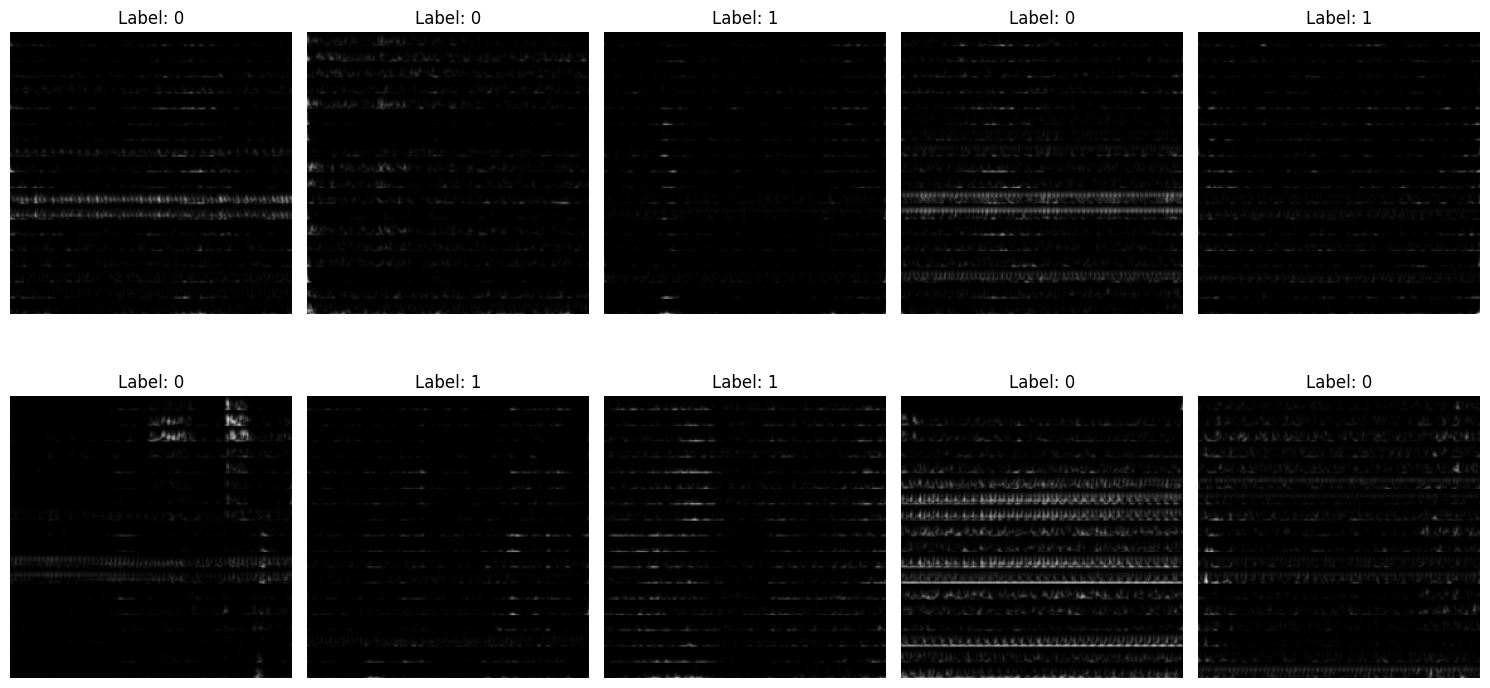

In [22]:
import torch
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

plt.figure(figsize=(15, 8))

for i in range(10):
    data_item = train_dataset[i]

    img = data_item["image"].cpu()
    img = img * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = img.clip(0, 1)

    y = data_item["label"]
    if hasattr(y, "item"):
        y = y.item()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {y}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
# train_labels = train_dataset.y
# class_counts = np.bincount(train_labels)
# print("Train class counts:", class_counts)

# class_weights = 1.0 / class_counts
# sample_weights = class_weights[train_labels]
# sample_weights = torch.from_numpy(sample_weights).double()

# sampler = WeightedRandomSampler(
#     weights=sample_weights,
#     num_samples=len(sample_weights),
#     replacement=True
# )

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=512,
#     sampler=sampler,
#     num_workers=2,
#     pin_memory=True,
#     drop_last=True,
# )

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)


val_loader = DataLoader(
    val_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [24]:
class MobileNetImageEncoder(nn.Module):
    def __init__(self, pretrained=True, out_dim=128):
        super().__init__()

        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        backbone = mobilenet_v3_small(weights=weights)

        self.features = backbone.features
        self.avgpool = backbone.avgpool

        # mobilenet_v3_small -> sau avgpool + flatten ra 576 chiều
        self.proj = nn.Linear(576, out_dim)
        self.out_dim = out_dim

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)   # (B, 576)
        x = self.proj(x)          # (B, out_dim)
        return x

class MobileNetClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, feat_dim=128):
        super().__init__()
        self.encoder = MobileNetImageEncoder(pretrained=pretrained, out_dim=feat_dim)
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feat = self.encoder(x)
        logits = self.classifier(feat)
        return logits

In [25]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Train", leave=False)

    for batch in pbar:
        img = batch["image"].to(device, non_blocking=True)
        label = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(img)
        loss = criterion(logits, label)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * img.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(label.detach().cpu().numpy())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return {
        "loss": epoch_loss,
        "acc": acc,
        "bal_acc": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [26]:
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Val", leave=False)

    for batch in pbar:
        img = batch["image"].to(device, non_blocking=True)
        label = batch["label"].to(device, non_blocking=True)

        logits = model(img)
        loss = criterion(logits, label)

        running_loss += loss.item() * label.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(label.cpu().numpy().tolist())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, zero_division=0)

    return {
        "loss": epoch_loss,
        "acc": acc,
        "bal_acc": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
        "report": report
    }

In [27]:
model = MobileNetClassifier(num_classes=2, pretrained=True, feat_dim=128).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [28]:
num_epochs = 50
best_val_f1 = -1.0

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch + 1}/{num_epochs}]")

    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = validate(model, val_loader, criterion, device)

    table = [
        [
            "Train",
            f"{train_metrics['loss']:.4f}",
            f"{train_metrics['acc']:.4f}",
            f"{train_metrics['bal_acc']:.4f}",
            f"{train_metrics['precision']:.4f}",
            f"{train_metrics['recall']:.4f}",
            f"{train_metrics['f1']:.4f}",
        ],
        [
            "Val",
            f"{val_metrics['loss']:.4f}",
            f"{val_metrics['acc']:.4f}",
            f"{val_metrics['bal_acc']:.4f}",
            f"{val_metrics['precision']:.4f}",
            f"{val_metrics['recall']:.4f}",
            f"{val_metrics['f1']:.4f}",
        ],
    ]

    print(tabulate(
        table,
        headers=["Split", "Loss", "Acc", "Bal Acc", "Precision", "Recall", "F1"],
        tablefmt="grid"
    ))

    print("Val confusion matrix:")
    print(val_metrics["cm"])
    print("Val classification report:")
    print(val_metrics["report"])

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), "best_eegnet_10m.pth")
        print("Saved best model.")


Epoch [1/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.5865 | 0.7672 |    0.7673 |      0.7701 |   0.7673 | 0.7666 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.6786 | 0.5612 |    0.5612 |      0.6715 |   0.5612 | 0.4772 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[432  17]
 [377  72]]
Val classification report:
              precision    recall  f1-score   support

           0       0.53      0.96      0.69       449
           1       0.81      0.16      0.27       449

    accuracy                           0.56       898
   macro avg       0.67      0.56      0.48       898
weighted avg       0.67      0.56      0.48       898

Saved best model.

Epoch [2/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.4565 | 0.8617 |    0.8617 |      0.8617 |   0.8617 | 0.8617 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.6586 | 0.6036 |    0.6036 |      0.7252 |   0.6036 | 0.5417 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[436  13]
 [343 106]]
Val classification report:
              precision    recall  f1-score   support

           0       0.56      0.97      0.71       449
           1       0.89      0.24      0.37       449

    accuracy                           0.60       898
   macro avg       0.73      0.60      0.54       898
weighted avg       0.73      0.60      0.54       898

Saved best model.

Epoch [3/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.3531 | 0.8844 |    0.8844 |      0.8846 |   0.8844 | 0.8844 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.6342 | 0.6581 |    0.6581 |      0.7531 |   0.6581 | 0.6228 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[433  16]
 [291 158]]
Val classification report:
              precision    recall  f1-score   support

           0       0.60      0.96      0.74       449
           1       0.91      0.35      0.51       449

    accuracy                           0.66       898
   macro avg       0.75      0.66      0.62       898
weighted avg       0.75      0.66      0.62       898

Saved best model.

Epoch [4/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.2735 | 0.9051 |    0.9051 |      0.9056 |   0.9051 | 0.905  |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.604  | 0.7483 |    0.7483 |      0.8011 |   0.7483 | 0.7368 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[430  19]
 [207 242]]
Val classification report:
              precision    recall  f1-score   support

           0       0.68      0.96      0.79       449
           1       0.93      0.54      0.68       449

    accuracy                           0.75       898
   macro avg       0.80      0.75      0.74       898
weighted avg       0.80      0.75      0.74       898

Saved best model.

Epoch [5/50]


...

+---------+--------+-------+-----------+-------------+----------+--------+
| Split   |   Loss |   Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+=======+===========+=============+==========+========+
| Train   | 0.0007 |   1   |       1   |        1    |      1   | 1      |
+---------+--------+-------+-----------+-------------+----------+--------+
| Val     | 1.8687 |   0.5 |       0.5 |        0.25 |      0.5 | 0.3333 |
+---------+--------+-------+-----------+-------------+----------+--------+
Val confusion matrix:
[[449   0]
 [449   0]]
Val classification report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       449
           1       0.00      0.00      0.00       449

    accuracy                           0.50       898
   macro avg       0.25      0.50      0.33       898
weighted avg       0.25      0.50      0.33       898


Epoch [47/50]


+---------+--------+-------+-----------+-------------+----------+--------+
| Split   |   Loss |   Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+=======+===========+=============+==========+========+
| Train   | 0.0007 |   1   |       1   |        1    |      1   | 1      |
+---------+--------+-------+-----------+-------------+----------+--------+
| Val     | 1.8102 |   0.5 |       0.5 |        0.25 |      0.5 | 0.3333 |
+---------+--------+-------+-----------+-------------+----------+--------+
Val confusion matrix:
[[449   0]
 [449   0]]
Val classification report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       449
           1       0.00      0.00      0.00       449

    accuracy                           0.50       898
   macro avg       0.25      0.50      0.33       898
weighted avg       0.25      0.50      0.33       898


Epoch [48/50]


+---------+--------+-------+-----------+-------------+----------+--------+
| Split   |   Loss |   Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+=======+===========+=============+==========+========+
| Train   | 0.0006 |   1   |       1   |        1    |      1   | 1      |
+---------+--------+-------+-----------+-------------+----------+--------+
| Val     | 1.7462 |   0.5 |       0.5 |        0.25 |      0.5 | 0.3333 |
+---------+--------+-------+-----------+-------------+----------+--------+
Val confusion matrix:
[[449   0]
 [449   0]]
Val classification report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       449
           1       0.00      0.00      0.00       449

    accuracy                           0.50       898
   macro avg       0.25      0.50      0.33       898
weighted avg       0.25      0.50      0.33       898


Epoch [49/50]


+---------+--------+-------+-----------+-------------+----------+--------+
| Split   |   Loss |   Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+=======+===========+=============+==========+========+
| Train   | 0.0006 |   1   |       1   |        1    |      1   | 1      |
+---------+--------+-------+-----------+-------------+----------+--------+
| Val     | 1.6768 |   0.5 |       0.5 |        0.25 |      0.5 | 0.3333 |
+---------+--------+-------+-----------+-------------+----------+--------+
Val confusion matrix:
[[449   0]
 [449   0]]
Val classification report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       449
           1       0.00      0.00      0.00       449

    accuracy                           0.50       898
   macro avg       0.25      0.50      0.33       898
weighted avg       0.25      0.50      0.33       898


Epoch [50/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.0005 | 1      |    1      |      1      |   1      | 1      |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 1.601  | 0.5022 |    0.5022 |      0.7506 |   0.5022 | 0.3383 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[449   0]
 [447   2]]
Val classification report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       449
           1       1.00      0.00      0.01       449

    accuracy                           0.50       898
   macro avg       0.75      0.50      0.34       898
weighted avg       0.75      0.50      0.34       898



In [29]:
import torch
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)


def load_model_checkpoint(model, checkpoint_path, device, strict=True):
    """
    Load checkpoint vào model.
    Hỗ trợ 2 kiểu lưu phổ biến:
    1. torch.save(model.state_dict(), path)
    2. torch.save({"model_state_dict": model.state_dict(), ...}, path)
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict):
        if "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]
        elif "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]
        else:
            # trường hợp checkpoint chính là state_dict
            state_dict = checkpoint
    else:
        raise ValueError("Checkpoint không hợp lệ. Không đọc được state_dict.")

    # Nếu model được train bằng DataParallel thì key có tiền tố 'module.'
    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    model.load_state_dict(state_dict, strict=strict)
    model.to(device)
    model.eval()

    return model


@torch.no_grad()
def evaluate_test(model, test_loader, criterion, device, checkpoint_path, strict=True, target_names=None):
    # Load model từ checkpoint (giữ nguyên hàm load_model_checkpoint của bạn)
    model = load_model_checkpoint(model, checkpoint_path, device, strict=strict)

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(test_loader, desc="Test", leave=False)

    for batch in pbar:
        # CHỈNH SỬA Ở ĐÂY: Sử dụng key "image" thay vì "signal" để khớp với Dataset
        # Nếu Dataset của bạn dùng key "image", hãy đổi lại như sau:
        inputs = batch["image"].to(device, non_blocking=True)
        label = batch["label"].to(device, non_blocking=True)

        # KIỂM TRA SHAPE (Debug): 
        # Nếu in ra [1, 512, 18, 1024] nghĩa là dữ liệu Wavelet chưa được xử lý thành ảnh 3 kênh
        # Bạn có thể cần thêm: if inputs.shape[1] == 512: inputs = inputs.mean(dim=1, keepdim=True).repeat(1, 3, 1, 1)
        
        logits = model(inputs)

        if criterion is not None:
            loss = criterion(logits, label)
            running_loss += loss.item() * label.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(label.cpu().numpy().tolist())

    epoch_loss = running_loss / len(test_loader.dataset) if criterion is not None else 0.0

    # Tính toán các chỉ số cơ bản
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    
    # Tính Precision, Recall, F1 (Macro)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    # Tính Confusion Matrix để trích xuất Sensitivity và Specificity
    cm = confusion_matrix(all_labels, all_preds)
    
    # Đối với bài toán nhị phân (0: Interictal, 1: Preictal)
    # cm.ravel() sẽ trả về: tn, fp, fn, tp
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        # Trường hợp multi-class hoặc dữ liệu thiếu class khi test
        sensitivity = recall_macro
        specificity = 0.0 # Cần định nghĩa riêng cho multi-class nếu cần

    report = classification_report(
        all_labels,
        all_preds,
        target_names=target_names,
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "acc": acc,
        "bal_acc": bal_acc,
        "precision": precision_macro,
        "recall": recall_macro,
        "f1": f1_macro,
        "sensitivity": sensitivity,   
        "specificity": specificity,   
        "cm": cm,
        "report": report,
        "preds": all_preds,
        "labels": all_labels
    }

In [30]:
from tabulate import tabulate

checkpoint_path = "/kaggle/working/best_eegnet_10m.pth"

test_results = evaluate_test(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    checkpoint_path=checkpoint_path,
    strict=True,
    target_names=['Interictal', 'Preictal']
)

# Chuẩn bị dữ liệu bảng
table = [
    [
        "Test",
        f"{test_results.get('loss', 0):.4f}",
        f"{test_results['acc']:.4f}",
        f"{test_results['bal_acc']:.4f}",
        f"{test_results['precision']:.4f}",
        f"{test_results['sensitivity']:.4f}", # Độ nhạy
        f"{test_results['specificity']:.4f}", # Độ đặc hiệu
        f"{test_results['f1']:.4f}",
    ]
]

headers = [
    "Split", 
    "Total Loss", 
    "Acc", 
    "Bal Acc", 
    "Precision", 
    "Sen", 
    "Spe", 
    "F1"
]

print(tabulate(table, headers=headers, tablefmt="grid"))
print("\nTest confusion matrix:")
print(test_results["cm"])
print("\nTest classification report:")
print(test_results["report"])

+---------+--------------+--------+-----------+-------------+--------+--------+--------+
| Split   |   Total Loss |    Acc |   Bal Acc |   Precision |    Sen |    Spe |     F1 |
+=========+==============+========+===========+=============+========+========+========+
| Test    |       0.5674 | 0.8047 |    0.8047 |      0.8461 | 0.6317 | 0.9777 | 0.7987 |
+---------+--------------+--------+-----------+-------------+--------+--------+--------+

Test confusion matrix:
[[438  10]
 [165 283]]

Test classification report:
              precision    recall  f1-score   support

  Interictal       0.73      0.98      0.83       448
    Preictal       0.97      0.63      0.76       448

    accuracy                           0.80       896
   macro avg       0.85      0.80      0.80       896
weighted avg       0.85      0.80      0.80       896

